In [1]:
import torch
import torchvision
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.preprocessing import label_binarize
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, auc, f1_score
from torchvision.datasets import ImageFolder
import torchvision.models as models
from torchvision import transforms
import matplotlib.pyplot as plt
from torch import amp
from pathlib import Path
from PIL import Image
import seaborn as sns
from tqdm import tqdm
import os
device = "cuda" if torch.cuda.is_available() else "cpu"


In [2]:
img_folder = Path("data")
dataset = ImageFolder(img_folder, transform=None)

class CustomDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        X, y = self.subset[index]
        if self.transform:
            X = self.transform(X)
        return X, y
    def __len__(self):
        return len(self.subset)

In [3]:
class_names = dataset.classes
class_idx = dataset.class_to_idx
class_names

['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

In [4]:
train_t = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5], std=[0.5])
])

test_t = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize([0.5], std=[0.5])
])

In [5]:
train_size = round(len(dataset) * 0.85)
val_size = round(len(dataset) * 0.10)
test_size = len(dataset) - (train_size + val_size)

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

train_set = CustomDataset(train_set, transform=train_t)
val_set   = CustomDataset(val_set,   transform=test_t)
test_set  = CustomDataset(test_set,  transform=test_t)

batch_size = 64

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=6)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=6)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=6)

In [6]:
model = torchvision.models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1).to(device)


In [7]:
class EarlyStopping:
    def __init__(self, patience=5, delta=1e-3):
        self.patience = patience
        self.delta = delta
        self.best_score = float("inf")
        self.counter = 0
    def __call__(self, acc):
        self.acc = acc
        if self.acc < self.best_score + self.delta:
            self.counter += 1
            if self.patience == self.counter:
                return True
        else:
            self.best_score = self.acc
            self.counter = 0
            torch.save(model.state_dict(), "best_model.pt")
            return False
        return False

In [ ]:
def train_model(model, dataloader, criterion, optimizer, scaler):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(dataloader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with amp.autocast(device_type=device, dtype=torch.float16):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
        total += images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (labels == preds).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc
        
def evaluate(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

epochs = 4
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

def test_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

def test_model_softmax(model, dataloader):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = nn.functional.softmax(outputs, 1)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_probs, all_labels

train_losses, val_losses = [], []
train_accs, val_accs = [], []

num_classes = len(class_names)

model.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False).to(device)
model.classifier = nn.Linear(model.classifier.in_features, num_classes).to(device)
scaler = amp.GradScaler(device)
early_stopping = EarlyStopping(patience=3)

for epoch in range(epochs):
    torch.cuda.empty_cache()
    train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, scaler)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    scheduler.step()
    if early_stopping(val_loss):
        print("Early stopping triggered!")
        break

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"  Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    print(f"  LR: {scheduler.get_last_lr()[0]:.6f}")
model.load_state_dict(torch.load("best_model.pt"))

100%|██████████| 34/34 [00:05<00:00,  5.97it/s]


Epoch 1/4
  Train Loss: 0.4477, Acc: 0.8383
  Val   Loss: 0.4126, Acc: 0.8587
  LR: 0.001000


100%|██████████| 34/34 [00:05<00:00,  6.08it/s]


Epoch 2/4
  Train Loss: 0.2841, Acc: 0.9004
  Val   Loss: 0.2865, Acc: 0.8922
  LR: 0.000100


100%|██████████| 34/34 [00:05<00:00,  5.97it/s]


Early stopping triggered!


FileNotFoundError: [Errno 2] No such file or directory: 'best_model.pt'

                 precision    recall  f1-score   support

          COVID       0.94      0.93      0.93       161
   Lung_Opacity       0.93      0.88      0.90       316
         Normal       0.92      0.96      0.94       513
Viral Pneumonia       1.00      0.91      0.95        69

       accuracy                           0.93      1059
      macro avg       0.95      0.92      0.93      1059
   weighted avg       0.93      0.93      0.93      1059



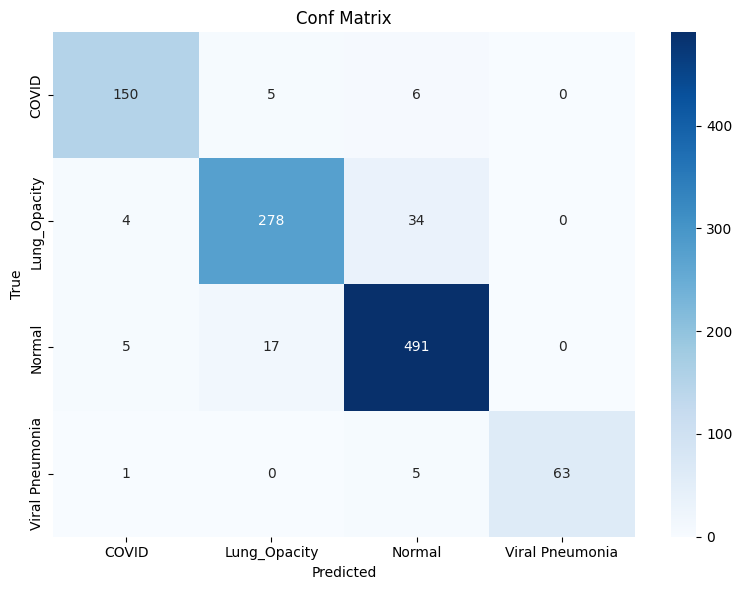

Macro ROC-AUC: 0.9895


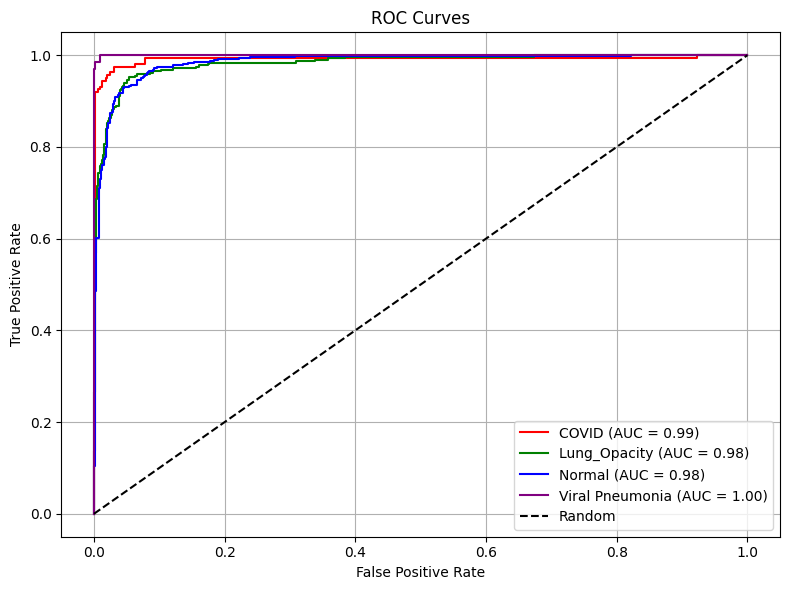

Macro f1: 0.9319629859195802


In [10]:
preds, labels = test_model(model, test_loader)
probs, labels = test_model_softmax(model, test_loader)
preds = np.argmax(probs, axis=1)

print(classification_report(labels, preds, target_names=class_names))

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues", 
            annot=True, 
            xticklabels=class_names, 
            yticklabels=class_names, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Conf Matrix")
plt.tight_layout()
plt.show()

y_true_bin = label_binarize(labels, classes=list(range(num_classes)))
y_score = np.array(probs)

fpr, tpr, roc_auc = dict(), dict(), dict()

for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    
macro_roc_auc = roc_auc_score(y_true_bin, y_score, average="macro", multi_class="ovr")
print(f"Macro ROC-AUC: {macro_roc_auc:.4f}")

plt.figure(figsize=(8,6))
colors = ["red", "green", "blue", "purple"]
for i in range(4):
    plt.plot(fpr[i], tpr[i], colors[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Macro f1:", f1_score(labels, preds,average="macro"))